# Мониторинг: дрифт данных и деградация модели

**reference = Kaggle** (~2018) vs **current = live** (ranked-матчи, собранные сегодня).
Дрифт заложен в дизайн проекта: игра изменилась за годы, поэтому замороженная на Kaggle
модель должна деградировать на живых данных. Здесь это измеряется (PSI/KS по фичам) и
показывается (наложение распределений обеих выборок), а также считается деградация MAE.

Логика вынесена в `pubg_ds.monitor.{drift,performance}` — ноутбук её только вызывает и рисует.

In [1]:
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pubg_ds import config
from pubg_ds.features import schema
from pubg_ds.monitor import drift, performance

sns.set_theme(style="whitegrid")

ref  = pd.read_parquet(config.DATA_PROCESSED / "reference.parquet")
live = pd.read_parquet(config.DATA_PROCESSED / "live.parquet")
ref_s = ref.sample(min(len(ref), 200_000), random_state=42)   # сэмпл reference для скорости графиков

params = config.load_params()["monitor"]
print(f"reference: {len(ref):,} строк | live: {len(live):,} строк, {live['matchId'].nunique()} матчей")

reference: 1,756,186 строк | live: 18,197 строк, 300 матчей


## 1. Data drift — PSI и KS по фичам

PSI: `< 0.1` стабильно, `0.1–0.25` умеренный сдвиг, `>= 0.25` сильный дрифт.

In [2]:
table = drift.compute()
table

,feature,psi,ks,level
0,matchDuration,2.916585,0.329854,strong
1,weaponsAcquired,1.784226,0.563992,strong
2,rideDistance,1.242546,0.497102,strong
3,boosts,1.009475,0.421610,strong
4,walkDistance,0.566570,0.299306,strong
5,heals,0.360369,0.261277,strong
6,longestKill,0.106871,0.112197,moderate
7,damageDealt,0.091432,0.124418,stable
8,DBNOs,0.014471,0.050487,stable
9,killStreaks,0.002441,0.014384,stable


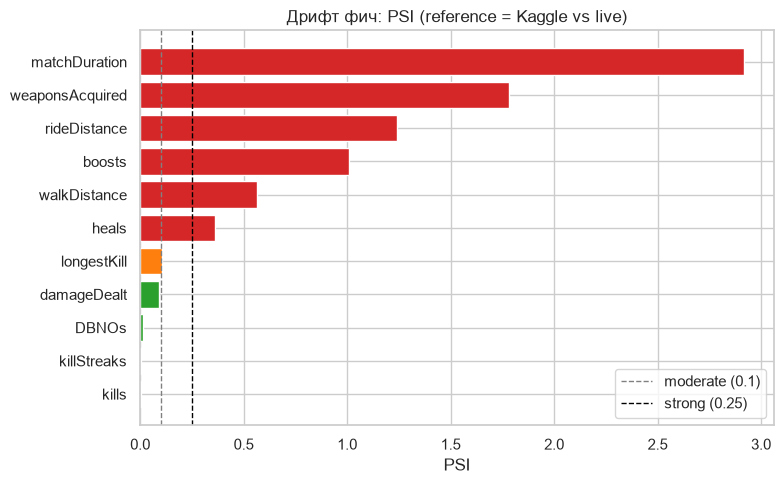

In [3]:
colors = {"strong": "#d62728", "moderate": "#ff7f0e", "stable": "#2ca02c"}

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(table["feature"], table["psi"], color=table["level"].map(colors))
ax.axvline(params["psi_moderate"], ls="--", c="gray",  lw=1, label="moderate (0.1)")
ax.axvline(params["psi_strong"],   ls="--", c="black", lw=1, label="strong (0.25)")
ax.invert_yaxis()
ax.set_xlabel("PSI")
ax.set_title("Дрифт фич: PSI (reference = Kaggle vs live)")
ax.legend()
plt.tight_layout()
plt.show()

## 2. Распределения фич: reference vs live

Шесть самых задрифтивших фич; хвосты обрезаны по 99-му перцентилю reference для читаемости.

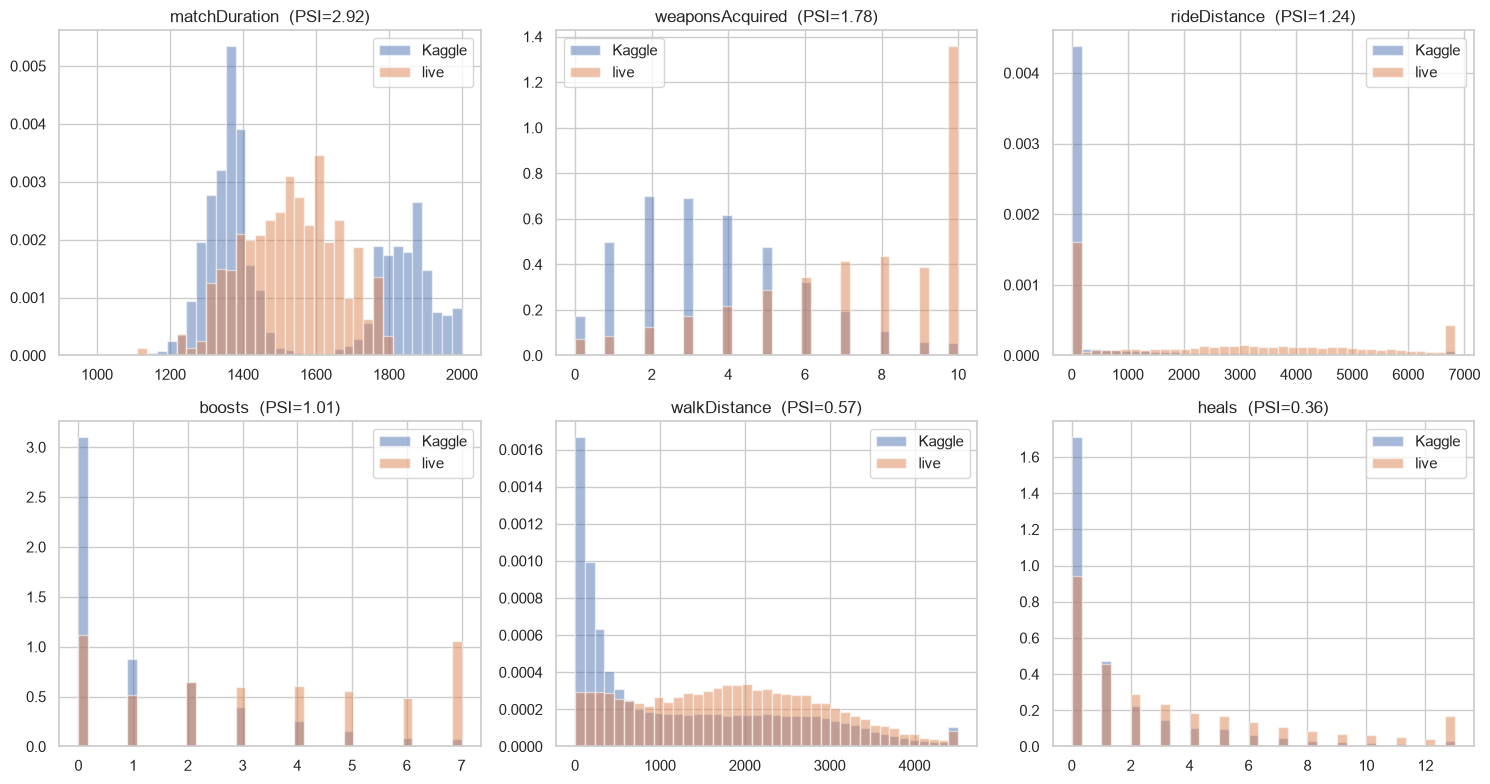

In [4]:
top = table["feature"].head(6).tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for feat, ax in zip(top, axes.ravel()):
    hi   = np.quantile(ref_s[feat], 0.99) or 1.0
    bins = np.linspace(float(min(ref_s[feat].min(), live[feat].min())), float(hi), 40)
    ax.hist(ref_s[feat].clip(upper=hi), bins=bins, density=True, alpha=0.5, label="Kaggle")
    ax.hist(live[feat].clip(upper=hi),  bins=bins, density=True, alpha=0.5, label="live")
    psi_val = float(table.loc[table.feature == feat, "psi"].iloc[0])
    ax.set_title(f"{feat}  (PSI={psi_val:.2f})")
    ax.legend()
plt.tight_layout()
plt.show()

## 3. Сдвиг таргета `winPlacePerc`

Таргет квантован сеткой `1/(maxPlace−1)`; сравниваем форму распределения на обеих выборках.

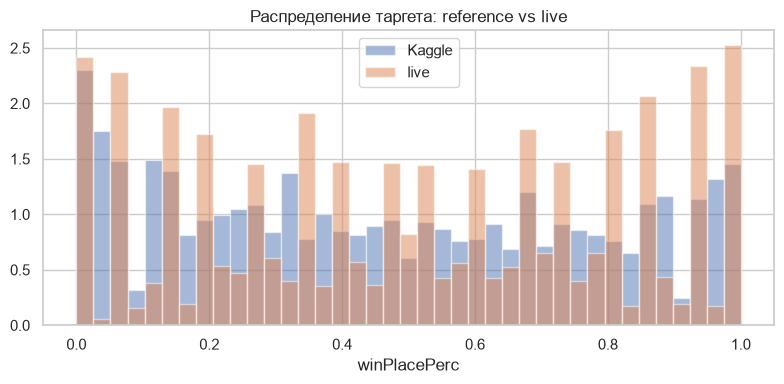

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
bins = np.linspace(0, 1, 40)
ax.hist(ref[schema.TARGET],  bins=bins, density=True, alpha=0.5, label="Kaggle")
ax.hist(live[schema.TARGET], bins=bins, density=True, alpha=0.5, label="live")
ax.set_xlabel("winPlacePerc")
ax.set_title("Распределение таргета: reference vs live")
ax.legend()
plt.tight_layout()
plt.show()

## 4. Деградация модели: frozen на live

Shadow scoring: API отдаёт завершённые матчи, поэтому предсказание и настоящий `winPlacePerc` доступны сразу.

In [6]:
perf = performance.degradation_summary()
perf

{'mae_kaggle_test': 0.05753897070275185,
 'mae_live_frozen': 0.12449323596707108,
 'degradation_abs': 0.06695426526431923,
 'degradation_pct': 116.36333505200692,
 'n_live_rows': 18197,
 'n_live_matches': 300}

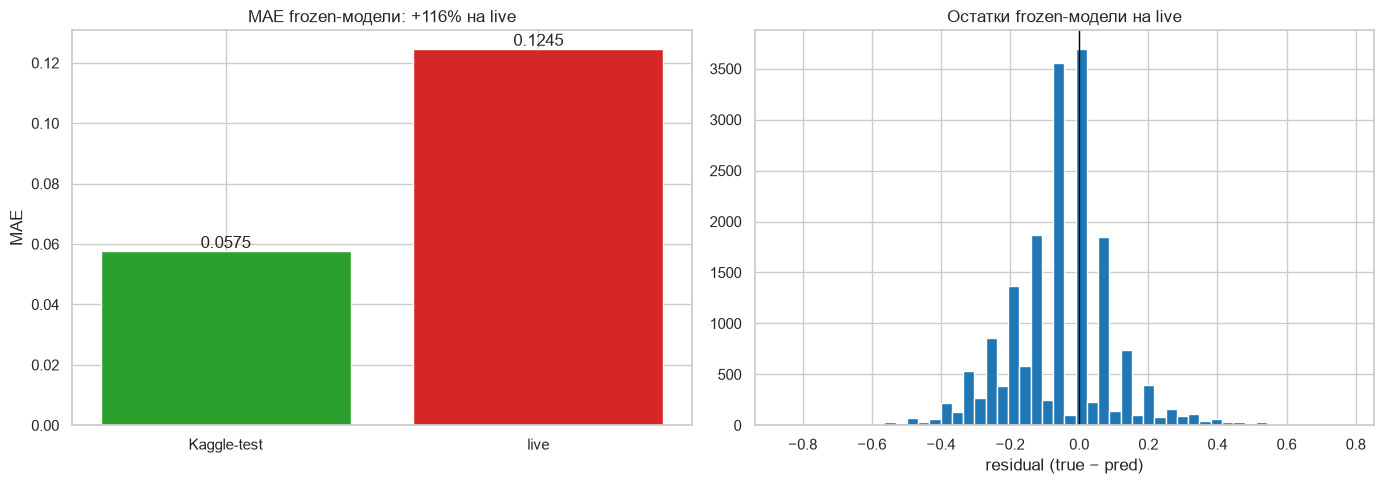

In [7]:
from pubg_ds.models.predict import load_model, predict

frozen = load_model(config.MODELS_DIR / "frozen_model.txt")
pred   = predict(frozen, live)
resid  = live[schema.TARGET].to_numpy() - pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# MAE: Kaggle-test vs live
axes[0].bar(["Kaggle-test", "live"],
            [perf["mae_kaggle_test"], perf["mae_live_frozen"]],
            color=["#2ca02c", "#d62728"])
axes[0].set_ylabel("MAE")
axes[0].set_title(f"MAE frozen-модели: +{perf['degradation_pct']:.0f}% на live")
for i, v in enumerate([perf["mae_kaggle_test"], perf["mae_live_frozen"]]):
    axes[0].text(i, v, f"{v:.4f}", ha="center", va="bottom")

# Остатки на live
axes[1].hist(resid, bins=50, color="#1f77b4")
axes[1].axvline(0, c="black", lw=1)
axes[1].set_xlabel("residual (true − pred)")
axes[1].set_title("Остатки frozen-модели на live")
plt.tight_layout()
plt.show()

## 5. Переобучение на live: замыкаем MLOps-петлю

Замороженную модель переобучаем на live-окне (те же гиперпараметры, новые данные) и
сравниваем frozen vs retrained на одном live-test. Результат `make retrain` лежит в
`reports/mae_comparison.json`.

In [8]:
comp_path = config.REPORTS_DIR / "mae_comparison.json"
assert comp_path.exists(), "сначала прогони `make retrain` (этап 8)"
comp = json.loads(comp_path.read_text())
comp

{'mae_kaggle_test_frozen': 0.05753897070275185,
 'mae_live_test_frozen': 0.12507671458416492,
 'mae_live_test_retrained': 0.1098528644368876,
 'degradation_frozen': 0.06753774388141306,
 'retrain_gain': 0.015223850147277312,
 'n_live_train_rows': 14573,
 'n_live_test_rows': 3624,
 'n_live_train_matches': 240,
 'n_live_test_matches': 60}

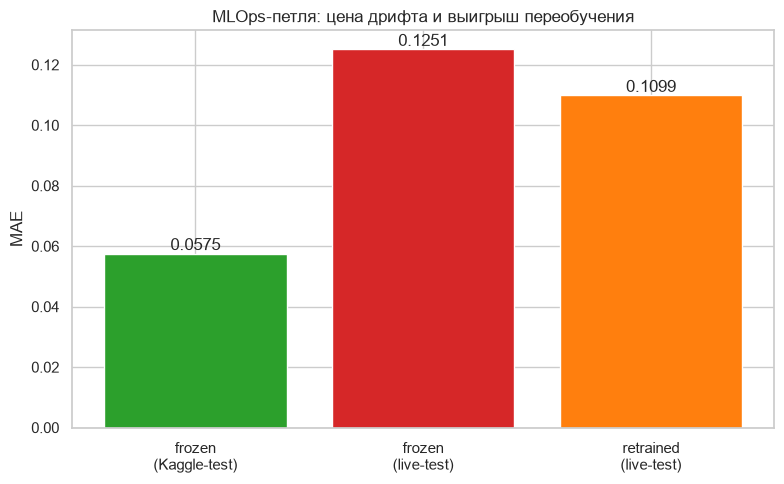

цена дрифта (frozen: Kaggle → live):        +0.0675  (117%)
выигрыш переобучения (frozen → retrained):  -0.0152  (12% от frozen-live)
live-окно: 240 train + 60 test матчей


In [9]:
labels = ["frozen\n(Kaggle-test)", "frozen\n(live-test)", "retrained\n(live-test)"]
vals   = [comp["mae_kaggle_test_frozen"], comp["mae_live_test_frozen"], comp["mae_live_test_retrained"]]
cols   = ["#2ca02c", "#d62728", "#ff7f0e"]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, vals, color=cols)
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v, f"{v:.4f}", ha="center", va="bottom")
ax.set_ylabel("MAE")
ax.set_title("MLOps-петля: цена дрифта и выигрыш переобучения")
plt.tight_layout()
plt.show()

deg  = comp["degradation_frozen"]
gain = comp["retrain_gain"]
print(f"цена дрифта (frozen: Kaggle → live):        +{deg:.4f}  ({deg / comp['mae_kaggle_test_frozen'] * 100:.0f}%)")
print(f"выигрыш переобучения (frozen → retrained):  -{gain:.4f}  ({gain / comp['mae_live_test_frozen'] * 100:.0f}% от frozen-live)")
print(f"live-окно: {comp['n_live_train_matches']} train + {comp['n_live_test_matches']} test матчей")

## Выводы

**Дрифт данных.** 6 из 11 сырых фич — в сильном дрифте (PSI ≥ 0.25), сильнее всего
`matchDuration`, `weaponsAcquired`, `rideDistance`, `boosts`, `walkDistance`, `heals`.
Kaggle-версия игры (~2018) и сегодняшний ranked заметно разошлись по геймплею.

**Деградация модели.** Замороженная на Kaggle модель на live даёт MAE вдвое хуже, чем на
Kaggle-test (см. бар выше) — дрифт данных транслируется в падение качества.

**Переобучение на live.** На том же live-test переобученная модель (те же
гиперпараметры, новые данные) отыгрывает часть ошибки, но до Kaggle-уровня не
возвращается: live-распределение объективно сложнее, плюс переобучение шло всего на
~240 матчах. Больше live-окно → выигрыш вырастет.

**Петля замкнута:** `make collect → live → monitor → retrain` — собрали live, измерили
дрифт (PSI/KS), показали деградацию MAE, переобучили и зафиксировали, сколько
отыгрывается. Все прогоны — в MLflow.